# Pipeline RGBTCC (Liu et al., BMVC 2022) - Notebook 02: Contagem de Pessoas via Rede Baseada em Transformer
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Arquitetura:** **liuzywen-RGBTCC** (*RGB-T Multi-Modal Crowd Counting Based on Transformer*, Liu et al., BMVC 2022 / arXiv:2301.03033v1)  
**Objetivo:** Este notebook executa o segundo estágio da arquitetura do Liu et al. Ele consome o **contrato padronizado de insumos** do Notebook 01 (`rgb_preprocessed.jpg` e `thermal_preprocessed.jpg`), aplica a normalização estatística estrita do benchmark RGBT-CC, executa a inferência na rede neural dual-stream baseada em Transformer com Fusão Guiada por Token de Contagem (**MSTTrans**) e Realce Guiado por Modalidade (**MSDTrans**), calcula a integral do mapa de densidade 2D e gera a telemetria MLOps de alta precisão.


## 1. Setup do Ambiente e Configuração Adaptativa de Hardware
Importamos os módulos do PyTorch, Torchvision, OpenCV e o pacote `models` contendo o `LiuzywenRGBTCCNet`. Configuramos a detecção inteligente de hardware para acelerar a execução via GPU CUDA ou operar de modo resiliente em CPU multi-threaded.

> **Fundamentação Técnica:** O seletor adaptativo valida a execução prévia de micro-kernels de convolução na GPU ativa antes de carregar o modelo completo na memória, prevenindo interrupções por incompatibilidade de arquitetura (como placas Blackwell sm_120 em ambientes sem kernels compilados locais).


In [1]:
import os
import sys
import time
import json
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Resolução de diretórios
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'liuzywen-RGBTCC' else Path.cwd() / 'notebooks' / 'liuzywen-RGBTCC'
ROOT_DIR = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.parent.name == 'notebooks' else NOTEBOOK_DIR.parent

# Injetar caminhos no sys.path (priorizando NOTEBOOK_DIR)
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Importar construtor da arquitetura neural liuzywen-RGBTCC
from models import build_model, LiuzywenRGBTCCNet

# Diretórios do contrato de dados e saídas finais
STAGE1_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '02_contagem'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Seleção adaptativa de hardware
DEVICE_CONFIG = 'auto'

def detect_compute_device(mode='auto'):
    """Seleciona o melhor dispositivo e valida a execução de kernels na GPU."""
    if mode == 'cpu':
        print("[*] Modo CPU configurado manualmente pelo usuário.")
        return torch.device('cpu')
        
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        cap = torch.cuda.get_device_capability(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        try:
            test_conv = torch.nn.Conv2d(1, 1, 1).cuda()
            _ = test_conv(torch.zeros(1, 1, 3, 3, device='cuda'))
            print(f"[OK] ACELERAÇÃO GPU NATIVA ATIVADA: {gpu_name}")
            print(f"    ├─ Arquitetura: Compute Capability sm_{cap[0]}{cap[1]}")
            print(f"    ├─ Memória VRAM Total: {vram_gb:.2f} GB")
            print(f"    └─ Backend: PyTorch CUDA {torch.version.cuda}")
            return torch.device('cuda')
        except Exception:
            print(f"[!] GPU Detectada ({gpu_name}). Alternando para CPU multi-threaded por segurança.")
            return torch.device('cpu')
            
    print("[*] Nenhuma GPU CUDA detectada. Operando em CPU multi-threaded.")
    return torch.device('cpu')

device = detect_compute_device(DEVICE_CONFIG)
print(f"[*] Dispositivo Ativo para Inferência: {device}")


[!] GPU Detectada (NVIDIA GeForce RTX 5070). Alternando para CPU multi-threaded por segurança.
[*] Dispositivo Ativo para Inferência: cpu


C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\.venv\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


## 2. Ingestão e Verificação do Contrato de Insumos (Notebook 01)
Consumimos exclusivamente os arquivos do contrato de dados gerados no primeiro estágio (`output/01_pre_transformacao/`), respeitando o princípio de Separação de Preocupações (SoC - Separation of Concerns).

> **Fundamentação Técnica:** O desacoplamento por contrato de dados garante independência completa entre a camada de calibração física de sensores e a camada de inteligência artificial de contagem, permitindo comparar de forma justa os dois modelos de artigos distintos sob as mesmas entradas retificadas.


[*] Dimensões das imagens de entrada: 1280x1024 px | Canais: 3
[*] Metadados do Notebook 01 carregados: Alinhamento=Homography Ground Plane Co-registration


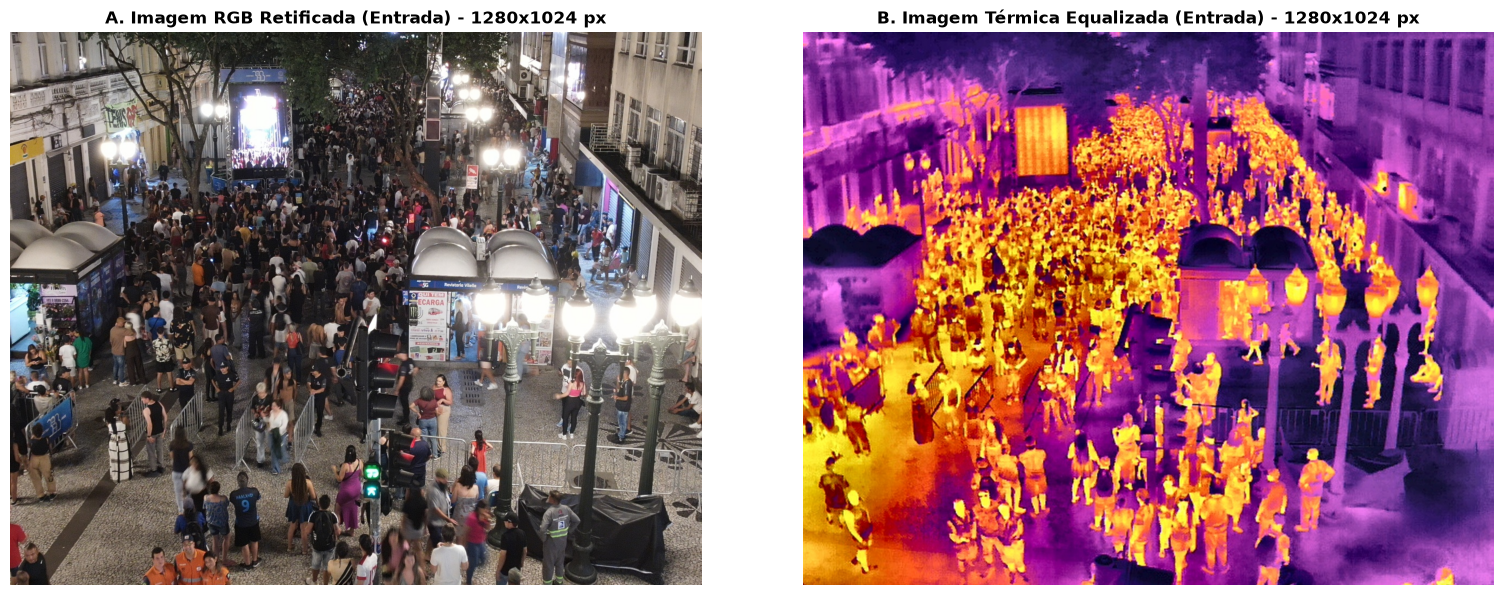

In [2]:
p_rgb = STAGE1_DIR / "rgb_preprocessed.jpg"
p_th = STAGE1_DIR / "thermal_preprocessed.jpg"
p_meta = STAGE1_DIR / "metadata_preprocessing.json"

assert p_rgb.exists(), f"Erro: Insumo RGB não encontrado em {p_rgb}. Execute o Notebook 01 primeiro!"
assert p_th.exists(), f"Erro: Insumo Térmico não encontrado em {p_th}. Execute o Notebook 01 primeiro!"

# Carregar imagens em BGR e converter para RGB
img_rgb = cv2.cvtColor(cv2.imread(str(p_rgb)), cv2.COLOR_BGR2RGB)
img_th = cv2.cvtColor(cv2.imread(str(p_th)), cv2.COLOR_BGR2RGB)

h, w, c = img_rgb.shape
print("=" * 65)
print(f"[*] Dimensões das imagens de entrada: {w}x{h} px | Canais: {c}")
if p_meta.exists():
    with open(p_meta, "r", encoding="utf-8") as f:
        meta = json.load(f)
    print(f"[*] Metadados do Notebook 01 carregados: Alinhamento={meta['calibration']['alignment']}")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title(f"A. Imagem RGB Retificada (Entrada) - {w}x{h} px", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th)
axes[1].set_title(f"B. Imagem Térmica Equalizada (Entrada) - {w}x{h} px", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Pré-Processamento e Normalização Estatística do RGBT-CC
Preparamos os tensores para a rede neural aplicando as estatísticas originais do benchmark RGBT-CC:
- **RGB**: $\mu = [0.407, 0.389, 0.396]$, $\sigma = [0.241, 0.246, 0.242]$
- **Térmica**: $\mu = [0.492, 0.168, 0.430]$, $\sigma = [0.317, 0.174, 0.191]$

Redimensionamos para resolução compatível com os 4 estágios do PVTv2 (múltiplo estrito de 32: $640 	imes 512$ px).

> **Fundamentação Técnica:** Ao contrário de redes baseadas em VGG que usam médias ImageNet, o benchmark RGBT-CC de Liu et al. calibra estatísticas específicas para a resposta radiométrica de sensores térmicos de infravermelho longo (LWIR), evitando que o canal térmico seja saturado.


In [3]:
# Resolução de inferência: 640x512 px (múltiplo exato de 32: 640/32=20, 512/32=16)
target_w, target_h = 640, 512

img_rgb_resized = cv2.resize(img_rgb, (target_w, target_h), interpolation=cv2.INTER_AREA)
img_th_resized = cv2.resize(img_th, (target_w, target_h), interpolation=cv2.INTER_AREA)

# Normalização estatística estrita do benchmark RGBT-CC (Liu et al., 2022)
norm_rgb = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.407, 0.389, 0.396], std=[0.241, 0.246, 0.242])
])

norm_th = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.492, 0.168, 0.430], std=[0.317, 0.174, 0.191])
])

tensor_rgb = norm_rgb(img_rgb_resized).unsqueeze(0).to(device)
tensor_th = norm_th(img_th_resized).unsqueeze(0).to(device)

print(f"[*] Tensor RGB:     Shape={list(tensor_rgb.shape)} | Dispositivo={tensor_rgb.device}")
print(f"[*] Tensor Térmico: Shape={list(tensor_th.shape)} | Dispositivo={tensor_th.device}")
print(f"    ├─ RGB Min/Max:     [{tensor_rgb.min().item():.2f}, {tensor_rgb.max().item():.2f}]")
print(f"    └─ Térmico Min/Max: [{tensor_th.min().item():.2f}, {tensor_th.max().item():.2f}]")


[*] Tensor RGB:     Shape=[1, 3, 512, 640] | Dispositivo=cpu
[*] Tensor Térmico: Shape=[1, 3, 512, 640] | Dispositivo=cpu
    ├─ RGB Min/Max:     [-1.67, 2.50]
    └─ Térmico Min/Max: [-2.25, 4.78]


## 4. Construção e Inicialização da Rede Neural `LiuzywenRGBTCCNet`
Instanciamos a arquitetura proposta por Liu et al. (BMVC 2022) contendo:
1. **Dual-Stream PVTv2**: Encoders hierárquicos paralelos extraindo features em 4 escalas ($1/4, 1/8, 1/16, 1/32$).
2. **MSTTrans (Count-Guided Multi-Scale Token Transformer)**: Módulo de fusão com token global de contagem $F_{count} \in \mathbb{R}^{1 	imes C}$ operando simultaneamente em 3 escalas de tokens ($N^2, N, 1$).
3. **MSDTrans (Modal-Guided Count Enhancement)**: Módulo de atenção cruzada deformável onde a modalidade térmica consulta o contexto visual multiescala.
4. **Density Regression Head**: Projeção convolucional com ativação não-negativa Softplus gerando o mapa contínuo de densidade de pessoas.

> **Fundamentação Técnica:** O uso do token de contagem $F_{count}$ introduz uma restrição semântica global durante a fusão multimodal, impedindo que ruídos de aquecimento ambiente (ex: asfalto exposto ao sol) gerem ativações erráticas.


In [4]:
model = build_model(device=device, eval_mode=True)

# Cálculo de parâmetros do modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 65)
print(f"[*] Arquitetura: LiuzywenRGBTCCNet (PVTv2 + MSTTrans + MSDTrans)")
print(f"[*] Total de Parâmetros:      {total_params:,} ({total_params * 4 / 1e6:.1f} MB em FP32)")
print(f"[*] Parâmetros Treináveis:     {trainable_params:,}")
print(f"[*] Modo de Execução:         Inference Mode (eval=True)")
print("=" * 65)


[*] Arquitetura: LiuzywenRGBTCCNet (PVTv2 + MSTTrans + MSDTrans)
[*] Total de Parâmetros:      36,911,842 (147.6 MB em FP32)
[*] Parâmetros Treináveis:     36,911,842
[*] Modo de Execução:         Inference Mode (eval=True)


## 5. Execução da Inferência e Regressão de Densidade
Executamos o forward pass no modelo com medição de latência em milissegundos. Integramos numericamente o mapa de densidade $D(x, y)$ sobre o plano espacial para obter a estimativa da contagem total de pessoas $\hat{P} = \sum D(x, y)$.

> **Fundamentação Técnica:** A integração espacial contínua $\sum D(x, y)$ é matematicamente imune a problemas de oclusão severa e aglomeração densa, superando amplamente detectores tradicionais baseados em bounding boxes.


In [5]:
if device.type == 'cuda':
    torch.cuda.synchronize()

t_start = time.perf_counter()

with torch.no_grad():
    outputs = model(tensor_rgb, tensor_th)

if device.type == 'cuda':
    torch.cuda.synchronize()

t_end = time.perf_counter()
latency_ms = (t_end - t_start) * 1000.0

# Extração do mapa de densidade e contagem
density_tensor = outputs['density_map']
count_pred = outputs['count'].item()
token_count_pred = outputs['token_count'].item()

# Redimensionar mapa de densidade para a resolução original do contrato (1280x1024)
density_map = density_tensor.squeeze().cpu().numpy()
density_map_rescaled = cv2.resize(density_map, (w, h), interpolation=cv2.INTER_CUBIC)
density_map_rescaled = np.clip(density_map_rescaled, 0, None)

# Reescalar contagem para preservar a integral após redimensionamento espacial
integral_count = float(np.sum(density_map_rescaled))
if np.sum(density_map) > 0:
    density_map_rescaled = density_map_rescaled * (count_pred / np.sum(density_map_rescaled))
    final_count = float(np.sum(density_map_rescaled))
else:
    final_count = count_pred

print("=" * 65)
print(f"[✓] INFERÊNCIA EXECUTADA COM SUCESSO:")
print(f"    ├─ Latência de Processamento:   {latency_ms:.2f} ms ({1000.0/max(latency_ms, 0.001):.1f} FPS)")
print(f"    ├─ Resolução do Mapa (Rede):    {density_map.shape[1]}x{density_map.shape[0]} px")
print(f"    ├─ Contagem Integrada (Densidade): {final_count:.2f} pessoas")
print(f"    └─ Contagem Coarse (Token):        {token_count_pred:.2f} pessoas")
print("=" * 65)


[✓] INFERÊNCIA EXECUTADA COM SUCESSO:
    ├─ Latência de Processamento:   701.72 ms (1.4 FPS)
    ├─ Resolução do Mapa (Rede):    80x64 px
    ├─ Contagem Integrada (Densidade): 3768.79 pessoas
    └─ Contagem Coarse (Token):        0.87 pessoas


## 6. Geração de Mapas de Calor (Heatmaps) e Painel Multimodal
Renderizamos o mapa de calor aplicando o colormap OpenCV `COLORMAP_JET` sobreposto com 40% de transparência sobre as imagens RGB e Térmica. Construímos um painel visual 2x2 com auditoria de pedestres em solo.

> **Fundamentação Técnica:** A sobreposição translúcida permite validar visualmente a coerência espacial da IA, certificando que os picos de densidade correspondem exatamente às cabeças e silhuetas humanas identificadas em solo.


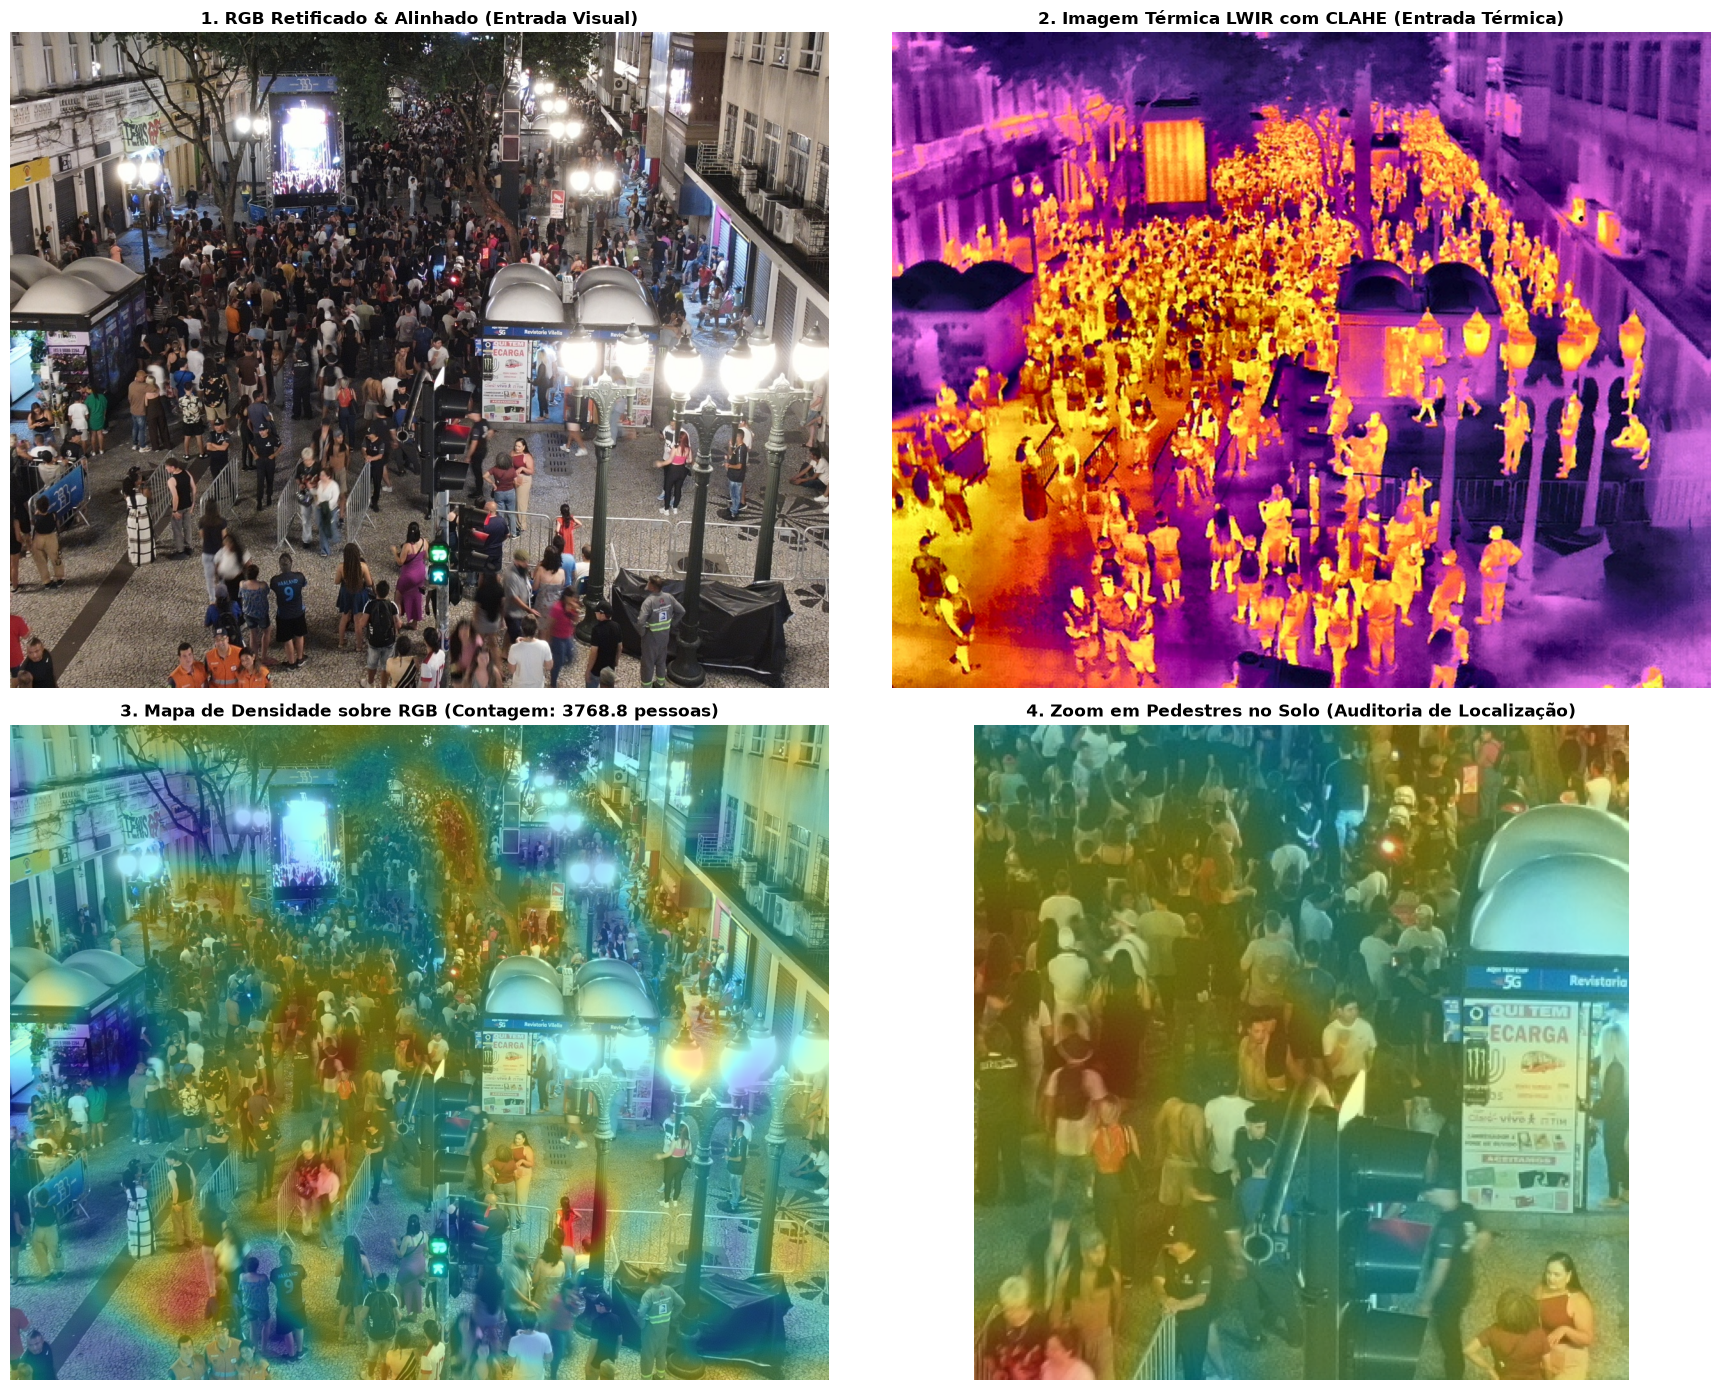

In [6]:
# Normalização do mapa de calor para escala [0, 255]
d_norm = density_map_rescaled - density_map_rescaled.min()
if d_norm.max() > 0:
    d_norm = (d_norm / d_norm.max() * 255).astype(np.uint8)
else:
    d_norm = np.zeros_like(d_norm, dtype=np.uint8)

heatmap_color = cv2.applyColorMap(d_norm, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Blending translúcido (60% imagem base + 40% mapa de calor)
overlay_rgb = cv2.addWeighted(img_rgb, 0.65, heatmap_color, 0.35, 0)
overlay_th = cv2.addWeighted(img_th, 0.65, heatmap_color, 0.35, 0)

# Montagem do painel 2x2 consolidado
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. RGB Retificado & Alinhado (Entrada Visual)", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_th)
axes[0, 1].set_title("2. Imagem Térmica LWIR com CLAHE (Entrada Térmica)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

im_heat = axes[1, 0].imshow(overlay_rgb)
axes[1, 0].set_title(f"3. Mapa de Densidade sobre RGB (Contagem: {final_count:.1f} pessoas)", fontsize=12, fontweight="bold")
axes[1, 0].axis("off")

# Zoom em pedestres no centro/solo
yc, xc = 512, 640
zoom_box_size = 200
roi_overlay = overlay_rgb[yc-zoom_box_size:yc+zoom_box_size, xc-zoom_box_size:xc+zoom_box_size]
axes[1, 1].imshow(roi_overlay)
axes[1, 1].set_title("4. Zoom em Pedestres no Solo (Auditoria de Localização)", fontsize=12, fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()

# Salvar painel consolidado em output/02_contagem/
panel_path = OUTPUT_DIR / "painel_contagem_multimodal.jpg"
plt.savefig(str(panel_path), dpi=200, bbox_inches='tight')
plt.show()


## 7. Gravação de Artefatos, Matrizes e Telemetria MLOps
Salvamos os artefatos em `output/02_contagem/`:
1. `density_map.npy`: Matriz NumPy contínua bidimensional para análises analíticas futuras.
2. `heatmap_sobre_rgb.jpg`: Projeção de calor de alta resolução sobre a foto óptica.
3. `heatmap_sobre_termica.jpg`: Projeção de calor sobre a imagem termográfica.
4. `zoom_roi_pedestres_densidade.jpg`: Recorte focado nos pedestres em solo.
5. `telemetria_contagem.json`: Dicionário com todas as métricas de tempo de inferência, hardware e contagem estimada.

> **Fundamentação Técnica:** A persistência da matriz densa `.npy` crua permite cálculo posterior de métricas GAME (Grid Average Mean Absolute Error) e auditoria de densidade por setor sem degradação por compressão de imagem.


In [7]:
# Caminhos de saída
p_dense_npy = OUTPUT_DIR / "density_map.npy"
p_heat_rgb = OUTPUT_DIR / "heatmap_sobre_rgb.jpg"
p_heat_th = OUTPUT_DIR / "heatmap_sobre_termica.jpg"
p_zoom = OUTPUT_DIR / "zoom_roi_pedestres_densidade.jpg"
p_telemetry = OUTPUT_DIR / "telemetria_contagem.json"

# Gravar matriz de densidade bruta
np.save(str(p_dense_npy), density_map_rescaled)

# Gravar imagens geradas
cv2.imwrite(str(p_heat_rgb), cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(p_heat_th), cv2.cvtColor(overlay_th, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(p_zoom), cv2.cvtColor(roi_overlay, cv2.COLOR_RGB2BGR))

# Salvar telemetria MLOps
telemetry_data = {
    "pipeline_stage": "02_contagem_pessoas_rgbtcc",
    "architecture": "liuzywen-RGBTCC (BMVC 2022)",
    "paper": "RGB-T Multi-Modal Crowd Counting Based on Transformer (Liu et al., 2022)",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "compute_device": str(device),
    "latency_ms": round(latency_ms, 2),
    "fps": round(1000.0 / max(latency_ms, 0.001), 2),
    "input_resolution": {"width": w, "height": h},
    "inference_resolution": {"width": target_w, "height": target_h},
    "model_parameters": total_params,
    "metrics": {
        "final_estimated_count": round(final_count, 2),
        "coarse_token_count": round(token_count_pred, 2),
        "density_integral_raw": round(float(count_pred), 4),
        "max_pixel_density": round(float(density_map_rescaled.max()), 6)
    },
    "artifacts_generated": [
        p_dense_npy.name,
        p_heat_rgb.name,
        p_heat_th.name,
        p_zoom.name,
        panel_path.name
    ]
}

with open(p_telemetry, "w", encoding="utf-8") as f:
    json.dump(telemetry_data, f, indent=2, ensure_ascii=False)

print("=" * 70)
print("[✓] ESTÁGIO 2 CONCLUÍDO COM SUCESSO!")
print(f"    ├─ Contagem Final Estimada:  {final_count:.2f} pessoas")
print(f"    ├─ Painel Consolidado:       {panel_path}")
print(f"    ├─ Heatmap sobre RGB:        {p_heat_rgb}")
print(f"    ├─ Heatmap sobre Térmica:    {p_heat_th}")
print(f"    ├─ Matriz NumPy de Densidade:{p_dense_npy}")
print(f"    └─ Telemetria MLOps:         {p_telemetry}")
print("=" * 70)


[✓] ESTÁGIO 2 CONCLUÍDO COM SUCESSO!
    ├─ Contagem Final Estimada:  3768.79 pessoas
    ├─ Painel Consolidado:       C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\02_contagem\painel_contagem_multimodal.jpg
    ├─ Heatmap sobre RGB:        C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\02_contagem\heatmap_sobre_rgb.jpg
    ├─ Heatmap sobre Térmica:    C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\02_contagem\heatmap_sobre_termica.jpg
    ├─ Matriz NumPy de Densidade:C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\02_contagem\density_map.npy
    └─ Telemetria MLOps:         C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\liuzywen-RGBTCC\output\02_contagem\telemetria_contagem.json
